# Task 1: Sales Forecasting Using Linear Regression

## Objective:
The objective of this project is to analyze historical sales data and build a machine learning model capable of forecasting future sales. Linear Regression is used to identify trends and predict future sales values based on historical patterns.

## Step 1: Importing Required Libraries

In this step, the necessary Python libraries are imported for data manipulation, visualization, machine learning model development, and performance evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Loading the Dataset

The sales dataset is loaded into a Pandas DataFrame. This dataset contains historical sales records along with store and promotional information that will be used for analysis and forecasting.

In [2]:
df = pd.read_csv("train.csv")

df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


## Step 3: Understanding the Dataset

This step examines the dataset structure, including the number of rows, columns, data types, and overall dataset characteristics.

In [6]:
print("Shape of Dataset:", df.shape)

info_df = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Non-Null Count': df.count().values
})

info_df.index.name = 'Column No.'
info_df.reset_index(inplace=True)

info_df

Shape of Dataset: (3000888, 6)


,Column No.,Column Name,Data Type,Non-Null Count
0,id,id,int64,3000888
1,date,date,object,3000888
2,store_nbr,store_nbr,int64,3000888
3,family,family,object,3000888
4,sales,sales,float64,3000888
5,onpromotion,onpromotion,int64,3000888


## Step 4: Checking Missing Values

Missing values can negatively impact model performance. Therefore, the dataset is inspected to identify and handle any missing information.

In [8]:
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum().values
})

missing_df

,Column,Missing Values
0,id,0
1,date,0
2,store_nbr,0
3,family,0
4,sales,0
5,onpromotion,0


## Step 5: Checking Duplicate Records

Duplicate records may introduce bias into the analysis. This step identifies and removes duplicate observations from the dataset.

In [ ]:
duplicate_df = pd.DataFrame({
    'Description': ['Duplicate Rows'],
    'Count': [df.duplicated().sum()]
})

duplicate_df

In [10]:
summary_df = df.describe()

summary_df

Column No.,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [11]:
dtype_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values
})

dtype_df

,Column,Data Type
0,id,int64
1,date,object
2,store_nbr,int64
3,family,object
4,sales,float64
5,onpromotion,int64


In [12]:
df['date'] = pd.to_datetime(df['date'])

df.head()

Column No.,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [13]:
sales_data = df.groupby('date', as_index=False)['sales'].sum()

sales_data.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


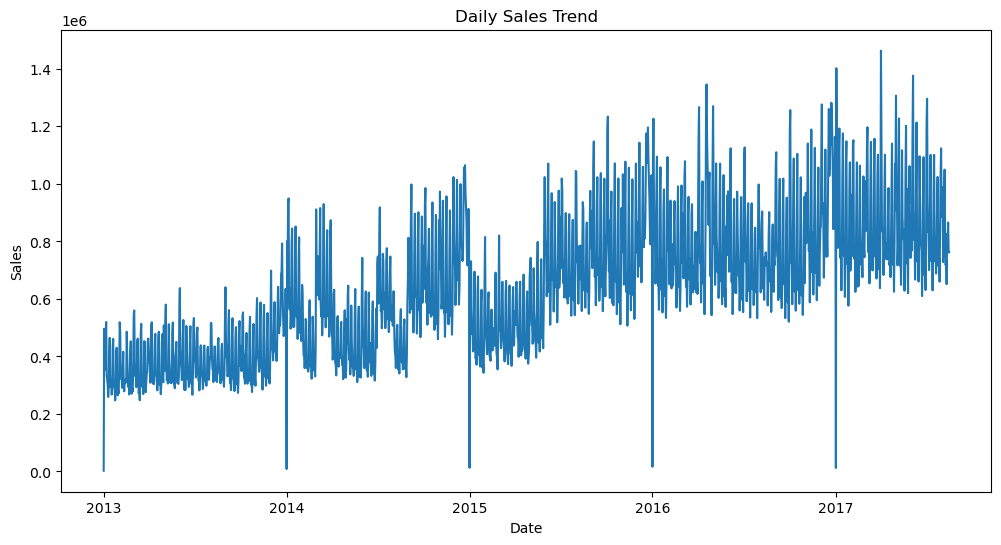

In [14]:
plt.figure(figsize=(12,6))

plt.plot(sales_data['date'], sales_data['sales'])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

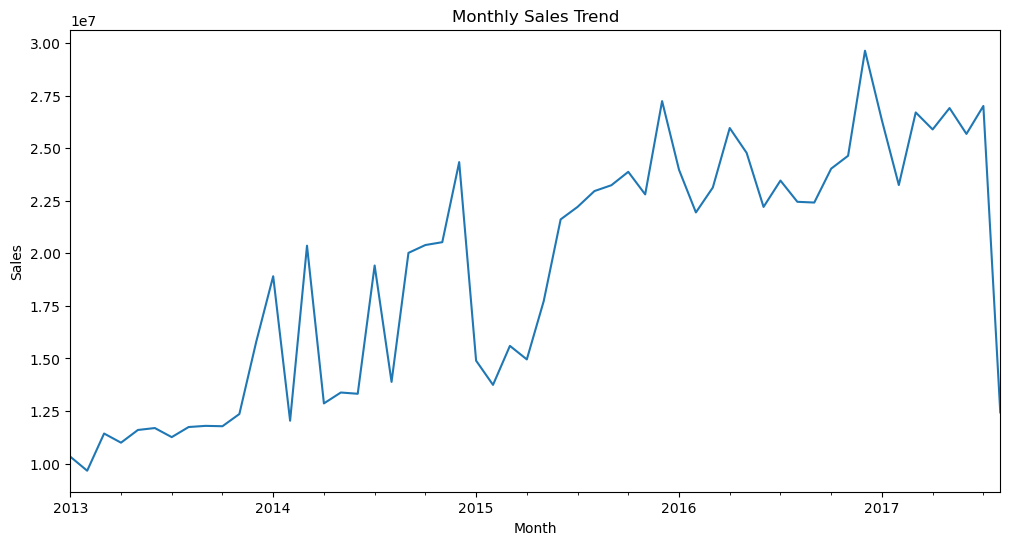

In [15]:
monthly_sales = sales_data.copy()

monthly_sales['Month'] = monthly_sales['date'].dt.to_period('M')

monthly_sales = monthly_sales.groupby('Month')['sales'].sum()

monthly_sales.plot(figsize=(12,6))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

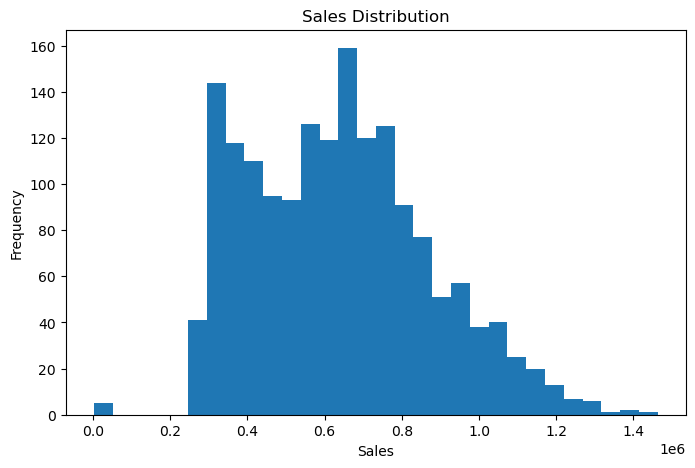

In [16]:
plt.figure(figsize=(8,5))

plt.hist(sales_data['sales'], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [17]:
sales_data['Day_Number'] = np.arange(len(sales_data))

sales_data.head()

,date,sales,Day_Number
0,2013-01-01,2511.618999,0
1,2013-01-02,496092.417944,1
2,2013-01-03,361461.231124,2
3,2013-01-04,354459.677093,3
4,2013-01-05,477350.121229,4


In [18]:
X = sales_data[['Day_Number']]

y = sales_data['sales']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = model.predict(X_test)

In [22]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 131035.91999232565
MSE : 26741546639.06751
RMSE : 163528.42761754763
R2 Score : 0.5213236778382915


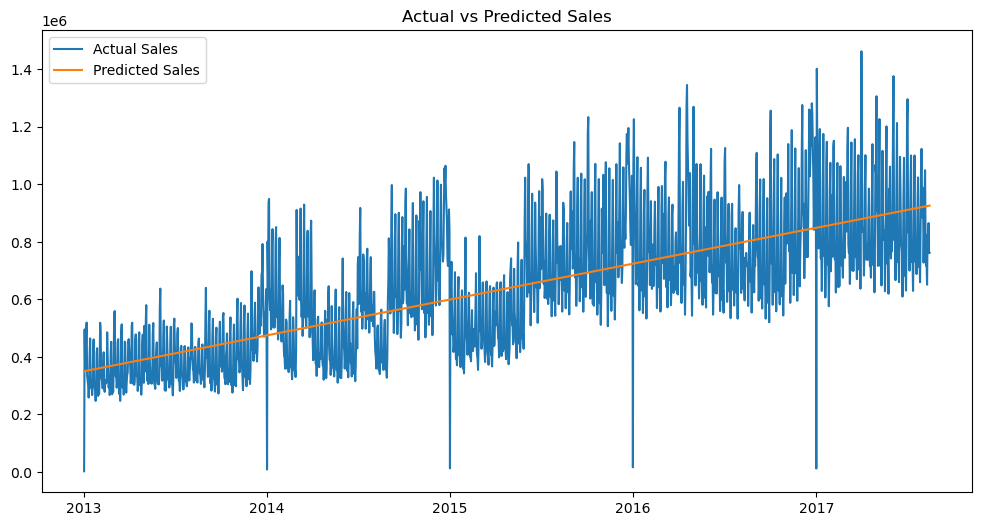

In [23]:
sales_data['Predicted_Sales'] = model.predict(X)

plt.figure(figsize=(12,6))

plt.plot(
    sales_data['date'],
    sales_data['sales'],
    label='Actual Sales'
)

plt.plot(
    sales_data['date'],
    sales_data['Predicted_Sales'],
    label='Predicted Sales'
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

In [28]:
future_days = 30

future_day_numbers = np.arange(
    len(sales_data),
    len(sales_data) + future_days
).reshape(-1,1)

future_predictions = model.predict(
    future_day_numbers
)

future_dates = pd.date_range(
    start=sales_data['date'].max() + pd.Timedelta(days=1),
    periods=future_days
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Sales': future_predictions
})

forecast_df

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Date,Predicted_Sales
0,2017-08-16,926805.222902
1,2017-08-17,927147.408306
2,2017-08-18,927489.593711
3,2017-08-19,927831.779115
4,2017-08-20,928173.964520
5,2017-08-21,928516.149924
6,2017-08-22,928858.335328
7,2017-08-23,929200.520733
8,2017-08-24,929542.706137
9,2017-08-25,929884.891541


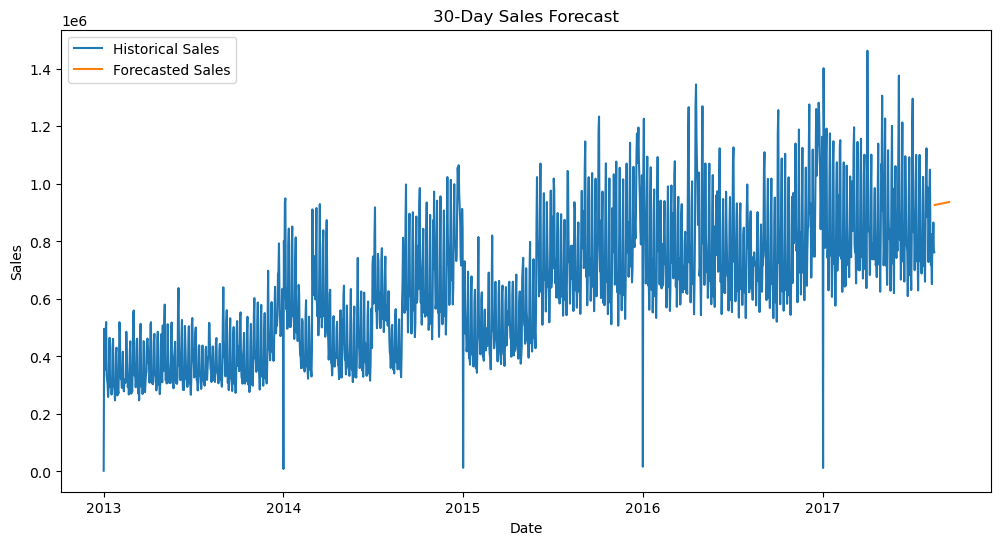

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    sales_data['date'],
    sales_data['sales'],
    label='Historical Sales'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Predicted_Sales'],
    label='Forecasted Sales'
)

plt.legend()

plt.title("30-Day Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

Conclusion:

1. The dataset was cleaned and preprocessed successfully.
2. Daily sales trends were analyzed using visualizations.
3. Linear Regression was used to build a forecasting model.
4. Model performance was evaluated using MAE, MSE, RMSE and R² Score.
5. Future sales for the next 30 days were forecasted successfully.
6. The project demonstrates the use of Machine Learning for sales forecasting and business planning.